# Spatial clustering with CAST + pymclustR

CAST is built for multi-slice single-cell-resolution spatial data.

This notebook runs the CAST spatial embedder on the
**Maynard 151676 dorsolateral prefrontal cortex** Visium sample
(3 460 spots × 10 747 genes) and clusters the resulting embedding with
[`pymclustR`](https://pypi.org/project/pymclustR/), a pure-Python
re-implementation of CRAN `mclust` (no `rpy2` / R dependency).

> Pre-processed input lives at
> `/scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/cluster_svg.h5ad`,
> which is the canonical fixture used in the original `t_cluster_space`
> tutorial.


## 0. Load AnnData + Ground Truth

In [1]:
import omicverse as ov
import scanpy as sc
import pandas as pd, os, anndata as ad

ov.style(font_path='Arial')

# Load the pre-processed AnnData (3460 spots × 10747 genes — the same
# input the original spatial-clustering tutorial was developed against).
DATA_DIR = '/scratch/users/steorra/analysis/omicverse_dev/omicverse-test/data/151676'
H5AD     = '/scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/cluster_svg.h5ad'
adata = ad.read_h5ad(H5AD)
truth = pd.read_csv(os.path.join(DATA_DIR, '151676_truth.txt'),
                    sep='\t', header=None, index_col=0)
truth.columns = ['Ground Truth']
adata.obs['Ground Truth'] = truth['Ground Truth'].reindex(adata.obs_names)
print('shape:', adata.shape, '  annotated:',
      adata.obs['Ground Truth'].notna().sum())
adata


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



shape: (3460, 10747)   annotated: 3431


AnnData object with n_obs × n_vars = 3460 × 10747
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'space_variable_features', 'highly_variable'
    uns: 'REFERENCE_MANU', 'spatial'
    obsm: 'spatial'
    layers: 'counts'

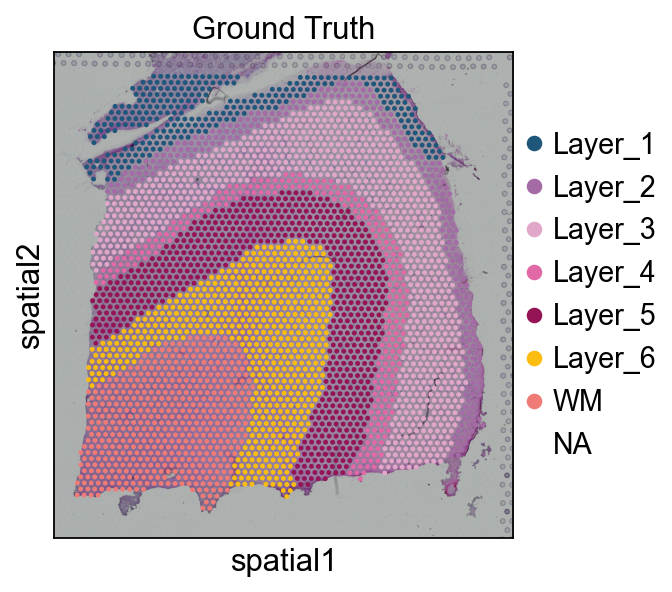

In [2]:
sc.pl.spatial(adata, img_key='hires', color=['Ground Truth'])

## 1. Embed with CAST

CAST (Tang et al., *Nat. Methods* 2024) is built for **multi-slice
single-cell-resolution spatial omics** — it learns a shared embedding
across slices that is useful for both within-slice clustering and
cross-slice matching.


The CAST method is used to embed the spatial data.


Constructing delaunay graphs for 1 samples...


Training on cuda:0...


  0%|                                                                                                             | 0/400 [00:00<?, ?it/s]

Loss: 26.687 step time=0.402s:   0%|                                                                              | 0/400 [00:00<?, ?it/s]

...

Loss: -403.867 step time=0.021s: 100%|██████████████████████████████████████████████████████████████████| 400/400 [00:09<00:00, 44.09it/s]

Finished.
The embedding, log, model files were saved to /tmp/CAST_pymclustR/output


  0%|                                                                                                               | 0/1 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 41.00it/s]

The CAST embedding are stored in adata.obsm["X_cast"]. 
Shape: (3460, 512)


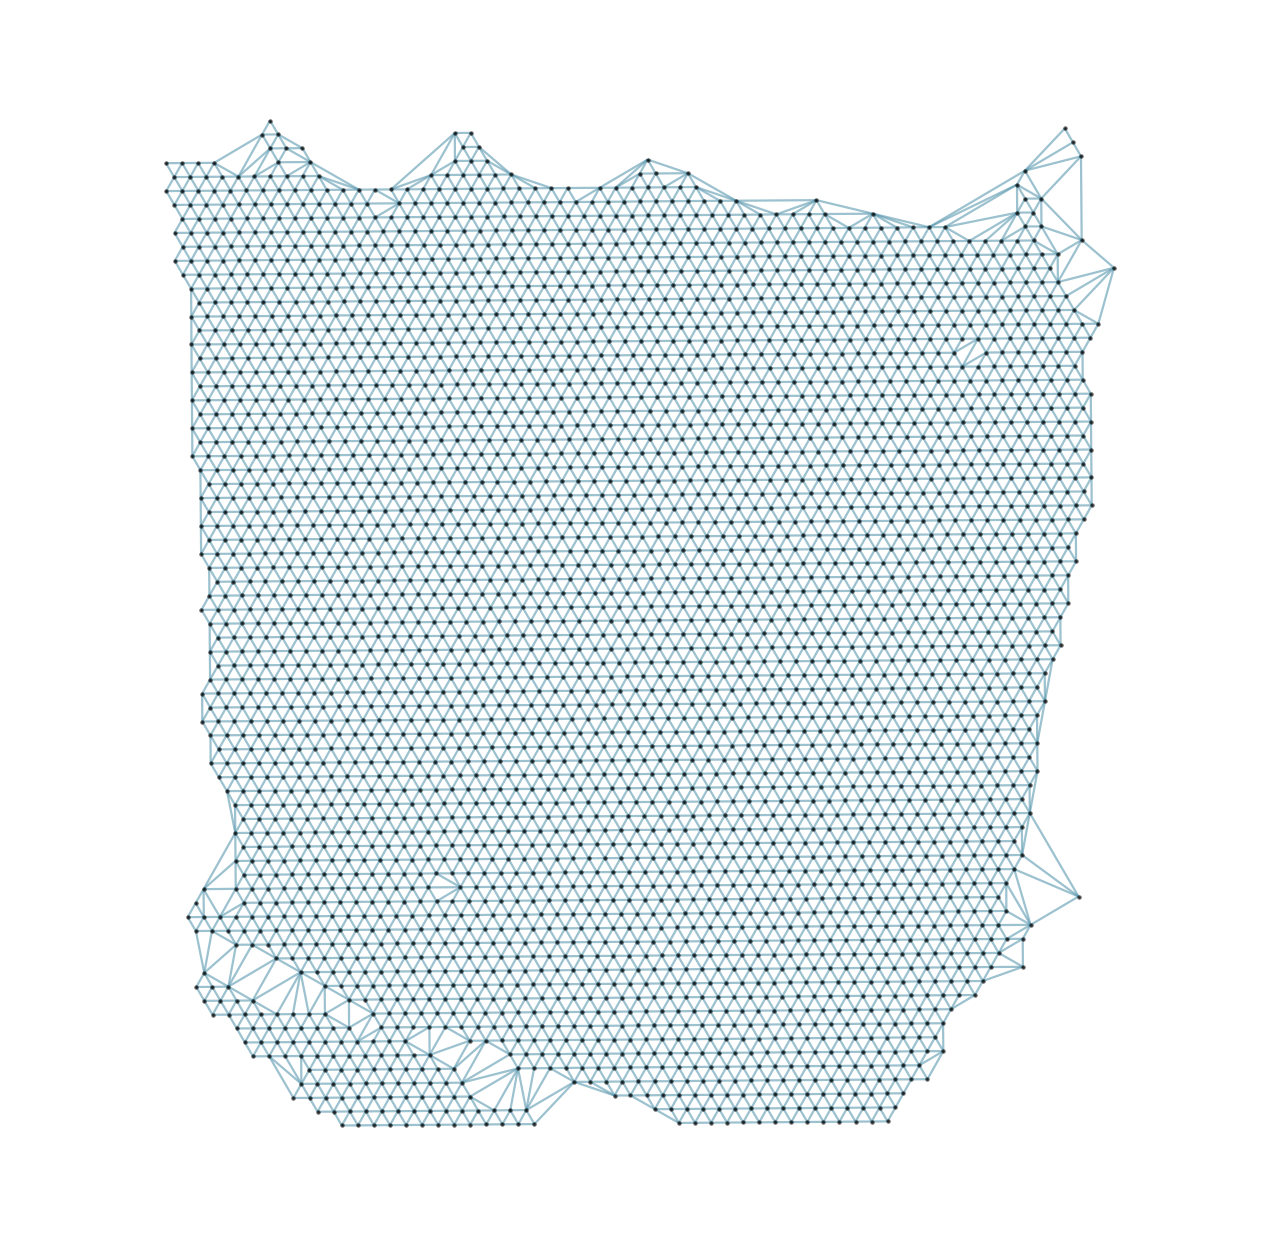

In [3]:
methods_kwargs = {'CAST': {
    'output_path_t': '/tmp/CAST_pymclustR/output',
    'device': 'cuda:0',
    'gpu_t': 0,
}}
adata = ov.space.clusters(adata, methods=['CAST'],
                          methods_kwargs=methods_kwargs)


## 2. Cluster with pymclustR (no rpy2 / R needed)


finished: found 10 clusters and added
    'pymclustR', the cluster labels (adata.obs, categorical)
    [model=EEE, loglik=-17978759.9496, BIC=-37069511.2492]


  0%|                                                                                                            | 0/3460 [00:00<?, ?it/s]

 25%|████████████████████████▎                                                                       | 876/3460 [00:00<00:00, 8751.83it/s]

 51%|████████████████████████████████████████████████                                               | 1752/3460 [00:00<00:00, 8748.80it/s]

 76%|████████████████████████████████████████████████████████████████████████▏                      | 2628/3460 [00:00<00:00, 8749.47it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 3460/3460 [00:00<00:00, 8750.68it/s]

The merged cluster information is stored in adata.obs["pymclustR_CAST_tree"].


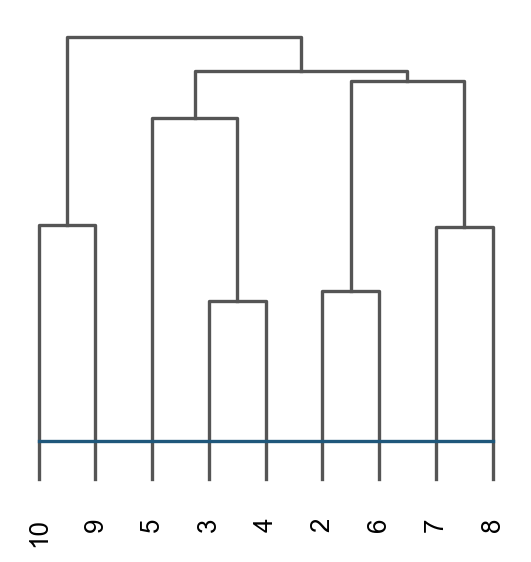

In [4]:
ov.utils.cluster(adata, use_rep='X_cast', method='pymclustR',
                 n_components=10, modelNames='EEE', random_state=42)
adata.obs['pymclustR_CAST'] = ov.utils.refine_label(adata, radius=50, key='pymclustR')
adata.obs['pymclustR_CAST'] = adata.obs['pymclustR_CAST'].astype('category')
res = ov.space.merge_cluster(adata, groupby='pymclustR_CAST',
                             use_rep='X_cast',
                             threshold=0.1, plot=True)


## 3. Spatial visualisation

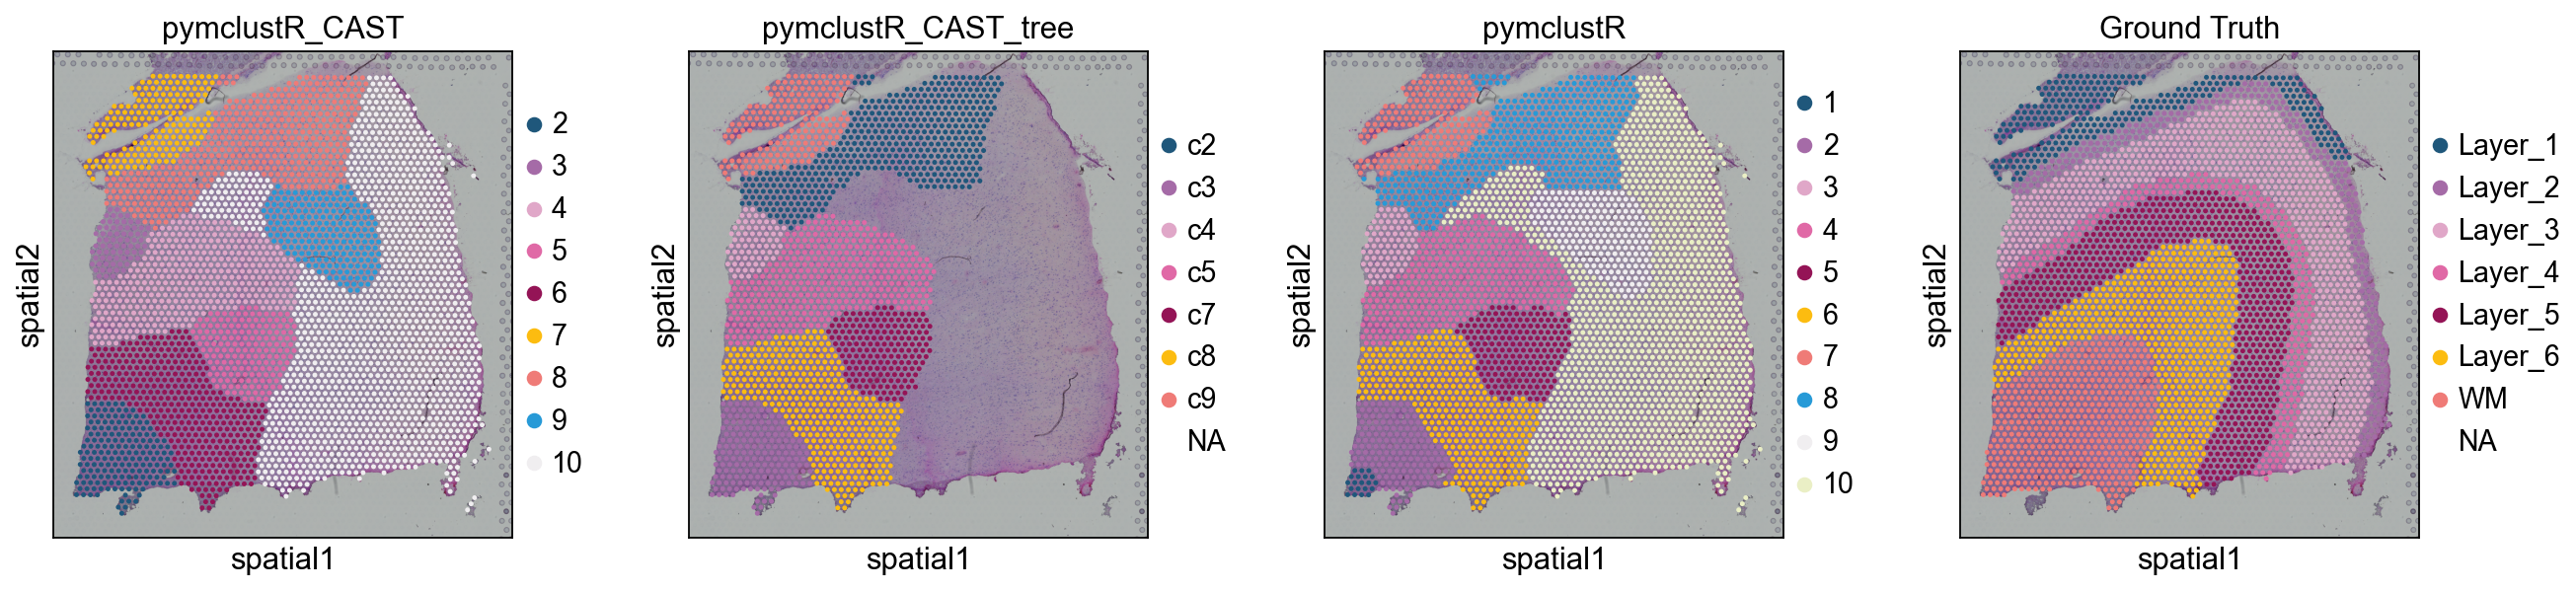

In [5]:
sc.pl.spatial(adata, color=['pymclustR_CAST',
                            'pymclustR_CAST_tree' if 'pymclustR_CAST_tree' in adata.obs.columns else 'pymclustR_CAST',
                            'pymclustR', 'Ground Truth'])


## 4. ARI vs Maynard ground truth

In [6]:
from sklearn.metrics.cluster import adjusted_rand_score

obs = adata.obs.dropna(subset=['Ground Truth'])
ari_raw = adjusted_rand_score(obs['pymclustR'], obs['Ground Truth'])
ari_ref = adjusted_rand_score(obs['pymclustR_CAST'], obs['Ground Truth'])
print(f'CAST + pymclustR (raw):     ARI = {ari_raw:.4f}')
print(f'CAST + pymclustR (refined): ARI = {ari_ref:.4f}')


CAST + pymclustR (raw):     ARI = 0.1995
CAST + pymclustR (refined): ARI = 0.2028
